In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [118]:
iris = load_iris()
X = iris.data[:,2:4]
y = iris.target

X = X[y != 2]
y = y[y != 2]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.33, random_state=42)

In [119]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

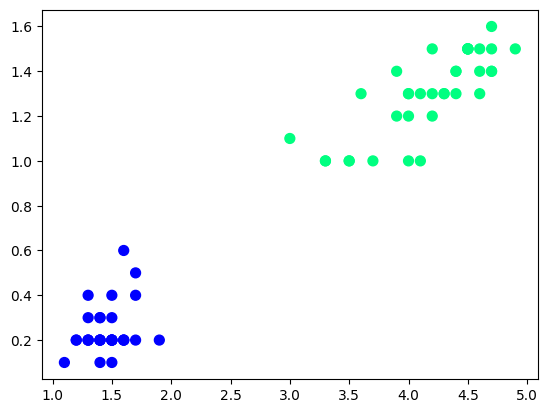

In [120]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter',s=50)
plt.show()

## Perceptron - Using Formula

In [121]:
def perceptron(X,y):
  X = np.insert(X, 0 , 1, axis = 1)
  W = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    s = np.random.randint(0, X.shape[0])
    y_hat = step(np.dot(X[s], W))
    W = W + lr * (y[s] - y_hat) * X[s]
  return W[0], W[1:]

def step(z):
  return 1 if z > 0 else 0

In [122]:
y_intersept, _coef = perceptron(X_train_scaler,y_train)

In [123]:
print(_coef)
print(y_intersept)

[1. 1.]
1.0


In [124]:
m = -(_coef[0] / _coef[1])
b = -(y_intersept / _coef[1])

In [125]:
X_input = np.linspace(-3, 3, 100)
y_input = m * X_input + b

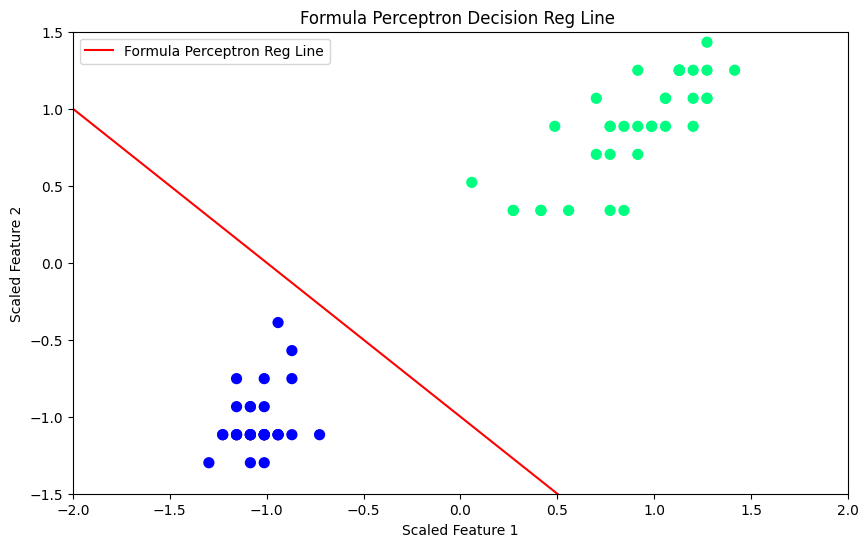

In [136]:
plt.figure(figsize=(10,6))
plt.plot(X_input, y_input, color='red', linestyle='-', label='Formula Perceptron Reg Line')
plt.scatter(X_train_scaler[:,0], X_train_scaler[:,1], c=y_train, cmap='winter',s=50)
plt.ylim(-1.5,1.5)
plt.xlim(-2,2)
plt.title('Formula Perceptron Decision Reg Line ')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()

## Using Sklearn

In [127]:
from sklearn.linear_model import Perceptron

sk_perceptron = Perceptron(random_state=42)
sk_perceptron.fit(X_train_scaler, y_train)

Perceptron(random_state=42)

In [128]:
sk_coef = sk_perceptron.coef_[0]
sk_intercept = sk_perceptron.intercept_[0]

# Calculate m and b for the decision boundary line
m_sk = -(sk_coef[0] / sk_coef[1])
b_sk = -(sk_intercept / sk_coef[1])

# Generate input for plotting the decision boundary
X_input_sk = np.linspace(-3, 3, 100)
y_input_sk = m_sk * X_input_sk + b_sk

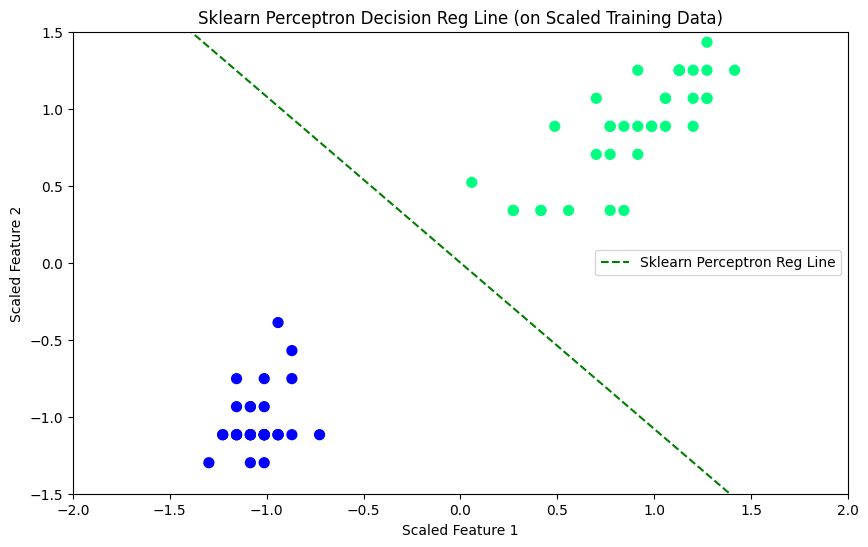

In [137]:
plt.figure(figsize=(10,6))
plt.plot(X_input_sk, y_input_sk, color='green', linestyle='--', label='Sklearn Perceptron Reg Line')
plt.scatter(X_train_scaler[:,0], X_train_scaler[:,1], c=y_train, cmap='winter',s=50) # Use scaled training data
plt.ylim(-1.5,1.5)
plt.xlim(-2,2)
plt.title('Sklearn Perceptron Decision Reg Line (on Scaled Training Data)')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()

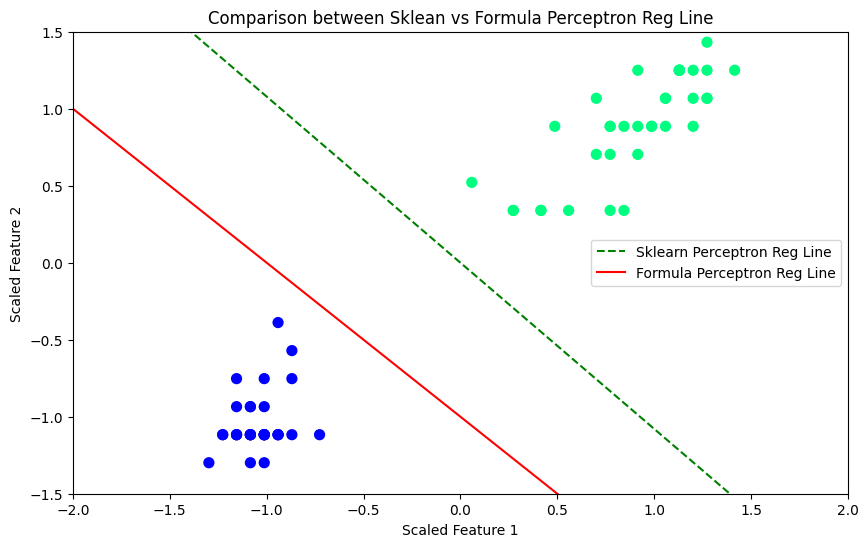

In [138]:
plt.figure(figsize=(10,6))
plt.plot(X_input_sk, y_input_sk, color='green', linestyle='--', label='Sklearn Perceptron Reg Line')
plt.plot(X_input, y_input, color='red', linestyle='-', label='Formula Perceptron Reg Line')
plt.scatter(X_train_scaler[:,0], X_train_scaler[:,1], c=y_train, cmap='winter',s=50) # Use scaled training data
plt.ylim(-1.5,1.5)
plt.xlim(-2,2)
plt.title('Comparison between Sklean vs Formula Perceptron Reg Line')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()